In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import accuracy_score

#### Overfitting

When your model **memorizes** the training data but **fails** on new data (train and test!).

Studying for a test by memorizing the answer key (training data)
But when the teacher gives new questions (test data), you fail!

#### Regularization

Techniques to **prevent overfitting**.


Learning concepts, not memorizing answers!

#### Common Regularization Techniques

| Technique | Description |
|-----------|-------------|
| **L1 (Lasso)** | Penalizes absolute weights → Feature selection |
| **L2 (Ridge)** | Penalizes squared weights → Shrinks weights |
| **Dropout** | Randomly drops neurons during training |
| **Early Stopping** | Stop training before overfitting |
| **Data Augmentation** | Create more training data |

In [5]:
print("\n" + "="*60)
print("CREATING AN OVERFITTED MODEL")
print("="*60)

# Load MNIST (but with very little data to cause overfitting)
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# Use only 500 training samples (to cause overfitting)
train_dataset = torchvision.datasets.MNIST(
    root='./data', train=True, download=True, transform=transform
)
test_dataset = torchvision.datasets.MNIST(
    root='./data', train=False, download=True, transform=transform
)

class OverfitModel(nn.Module):
    def __init__(self):
        super(OverfitModel, self).__init__()
        self.flatten = nn.Flatten()
        # Too many parameters for 500 samples! it definitly leads to overfitting!
        self.fc1 = nn.Linear(28*28, 512)
        self.fc2 = nn.Linear(512, 512)
        self.fc3 = nn.Linear(512, 512)
        self.fc4 = nn.Linear(512, 10)
        self.relu = nn.ReLU()
    
    def forward(self, x):
        x = self.flatten(x)
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.relu(self.fc3(x))
        x = self.fc4(x)
        return x

m = OverfitModel()

# Create dataloaders
train_loader_small = torch.utils.data.DataLoader(
    torch.utils.data.Subset(train_dataset, range(500)),
    batch_size=64, shuffle=True
)
test_loader = torch.utils.data.DataLoader(
    test_dataset, batch_size=64, shuffle=False
)

print(m)


CREATING AN OVERFITTED MODEL
OverfitModel(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=784, out_features=512, bias=True)
  (fc2): Linear(in_features=512, out_features=512, bias=True)
  (fc3): Linear(in_features=512, out_features=512, bias=True)
  (fc4): Linear(in_features=512, out_features=10, bias=True)
  (relu): ReLU()
)


In [6]:
print("\n" + "="*60)
print("TRAINING OVERFITTED MODEL")
print("="*60)

def train_model(model, train_loader, test_loader, epochs=30, lr=0.001):
    """Train model and track train/test accuracies"""
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    
    train_acc_history = []
    test_acc_history = []
    
    for epoch in range(epochs):
        # Training
        model.train()
        correct_train = 0
        total_train = 0
        for images, labels in train_loader:
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            _, predicted = torch.max(outputs.data, 1)
            total_train += labels.size(0)
            correct_train += (predicted == labels).sum().item()
        
        train_acc = 100 * correct_train / total_train
        train_acc_history.append(train_acc)
        
        # Testing
        model.eval()
        correct_test = 0
        total_test = 0
        with torch.no_grad():
            for images, labels in test_loader:
                outputs = model(images)
                _, predicted = torch.max(outputs.data, 1)
                total_test += labels.size(0)
                correct_test += (predicted == labels).sum().item()
        
        test_acc = 100 * correct_test / total_test
        test_acc_history.append(test_acc)
        
        if epoch % 5 == 0:
            print(f"Epoch {epoch}: Train={train_acc:.2f}%, Test={test_acc:.2f}%")
    
    return train_acc_history, test_acc_history

# Train overfitted model
print("Training overfitted model (too complex, too little data)...")
overfit_model = OverfitModel()
train_acc_overfit, test_acc_overfit = train_model(
    overfit_model, train_loader_small, test_loader, epochs=30
)



TRAINING OVERFITTED MODEL
Training overfitted model (too complex, too little data)...
Epoch 0: Train=25.60%, Test=43.57%
Epoch 5: Train=89.20%, Test=79.08%
Epoch 10: Train=97.00%, Test=80.56%
Epoch 15: Train=99.40%, Test=83.20%
Epoch 20: Train=100.00%, Test=83.66%
Epoch 25: Train=100.00%, Test=83.98%



VISUALIZING OVERFITTING


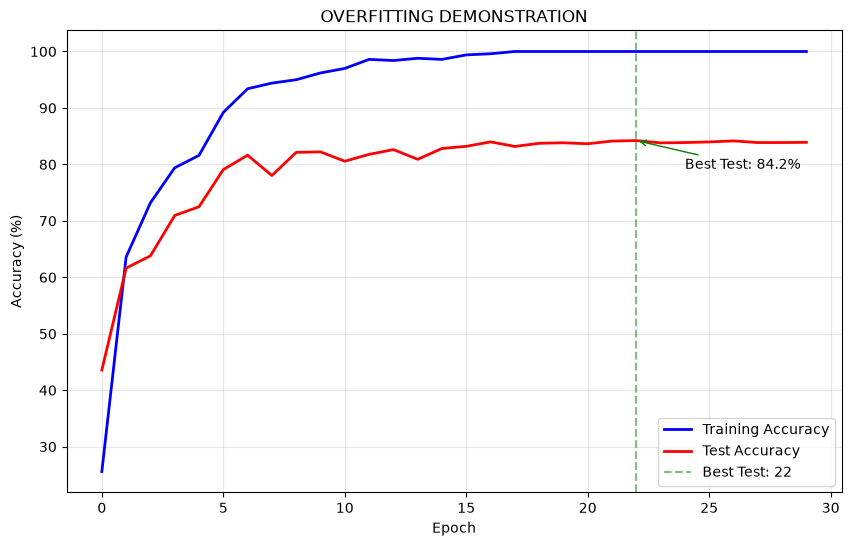


OVERFITTING OBSERVED:
Max Training Accuracy: 100.00%
Max Test Accuracy: 84.22%
Overfitting Gap: 15.78%
Best Test at Epoch: 22

⚠️  Notice: Training accuracy keeps going up, but test accuracy starts decreasing!
   This is the classic sign of overfitting!


In [12]:
print("\n" + "="*60)
print("VISUALIZING OVERFITTING")
print("="*60)

def plot_train_and_test_accuracy(train_acc, test_acc):
    plt.figure(figsize=(10, 6))
    plt.plot(train_acc, 'b-', linewidth=2, label='Training Accuracy')
    plt.plot(test_acc, 'r-', linewidth=2, label='Test Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy (%)')
    plt.title('OVERFITTING DEMONSTRATION')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Highlight the overfitting point
    max_test_idx = np.argmax(test_acc)
    plt.axvline(x=max_test_idx, color='green', linestyle='--', alpha=0.5, label=f'Best Test: {max_test_idx}')
    plt.annotate(f'Best Test: {test_acc[max_test_idx]:.1f}%', 
                 xy=(max_test_idx, test_acc[max_test_idx]),
                 xytext=(max_test_idx+2, test_acc[max_test_idx]-5),
                 arrowprops=dict(arrowstyle='->', color='green'))
    plt.legend()
    plt.show()

plot_train_and_test_accuracy(train_acc_overfit, test_acc_overfit)

print("\n" + "="*60)
print("OVERFITTING OBSERVED:")
print("="*60)
print(f"Max Training Accuracy: {max(train_acc_overfit):.2f}%")
print(f"Max Test Accuracy: {max(test_acc_overfit):.2f}%")
print(f"Overfitting Gap: {max(train_acc_overfit) - max(test_acc_overfit):.2f}%")
print(f"Best Test at Epoch: {max_test_idx}")
print("\n⚠️  Notice: Training accuracy keeps going up, but test accuracy starts decreasing!")
print("   This is the classic sign of overfitting!")

### DROPOUT REGULARIZATION


DROPOUT REGULARIZATION
Training with Dropout (p=0.5)...
Epoch 0: Train=12.20%, Test=47.67%
Epoch 5: Train=67.40%, Test=70.17%
Epoch 10: Train=82.20%, Test=79.81%
Epoch 15: Train=89.20%, Test=83.14%
Epoch 20: Train=92.20%, Test=82.51%
Epoch 25: Train=96.00%, Test=84.35%


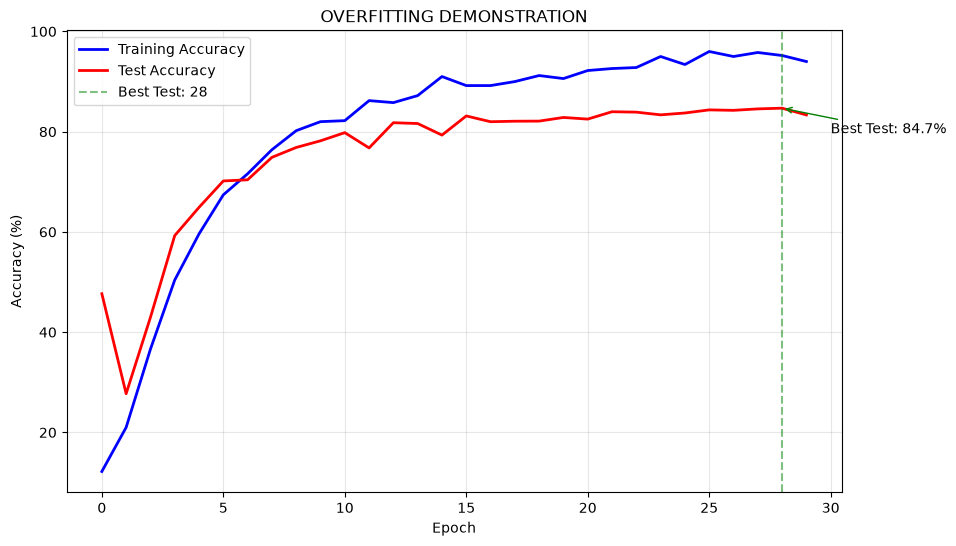

In [13]:
print("\n" + "="*60)
print("DROPOUT REGULARIZATION")
print("="*60)

class DropoutModel(nn.Module):
    def __init__(self, dropout_rate=0.5):
        super(DropoutModel, self).__init__()
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(28*28, 512)
        self.fc2 = nn.Linear(512, 512)
        self.fc3 = nn.Linear(512, 512)
        self.fc4 = nn.Linear(512, 10)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(dropout_rate)
    
    def forward(self, x):
        x = self.flatten(x)
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.relu(self.fc2(x))
        x = self.dropout(x)
        x = self.relu(self.fc3(x))
        x = self.dropout(x)
        x = self.fc4(x)
        return x

print("Training with Dropout (p=0.5)...")
dropout_model = DropoutModel(dropout_rate=0.5)
train_acc_dropout, test_acc_dropout = train_model(
    dropout_model, train_loader_small, test_loader, epochs=30
)


# plot 
plot_train_and_test_accuracy(train_acc_dropout, test_acc_dropout)

### L2 REGULARIZATION (Weight Decay)


L2 REGULARIZATION (Weight Decay)
Training with L2 Regularization (weight_decay=0.001)...


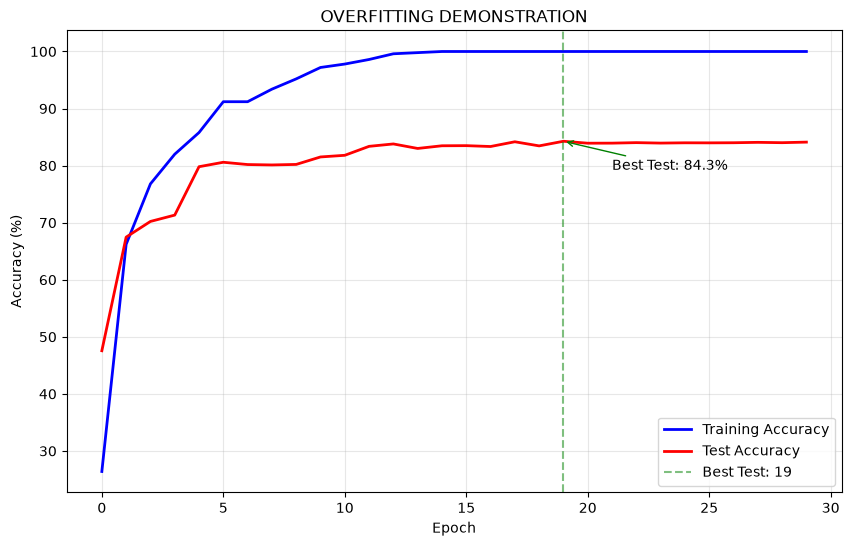

In [14]:
print("\n" + "="*60)
print("L2 REGULARIZATION (Weight Decay)")
print("="*60)

class L2Model(nn.Module):
    def __init__(self):
        super(L2Model, self).__init__()
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(28*28, 512)
        self.fc2 = nn.Linear(512, 512)
        self.fc3 = nn.Linear(512, 512)
        self.fc4 = nn.Linear(512, 10)
        self.relu = nn.ReLU()
    
    def forward(self, x):
        x = self.flatten(x)
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.relu(self.fc3(x))
        x = self.fc4(x)
        return x

def train_with_l2(weight_decay=0.001):
    model = L2Model()
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=weight_decay)
    
    train_acc, test_acc = [], []
    
    for epoch in range(30):
        # Training
        model.train()
        correct_train = 0
        total_train = 0
        for images, labels in train_loader_small:
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            _, predicted = torch.max(outputs.data, 1)
            total_train += labels.size(0)
            correct_train += (predicted == labels).sum().item()
        
        train_acc.append(100 * correct_train / total_train)
        
        # Testing
        model.eval()
        correct_test = 0
        total_test = 0
        with torch.no_grad():
            for images, labels in test_loader:
                outputs = model(images)
                _, predicted = torch.max(outputs.data, 1)
                total_test += labels.size(0)
                correct_test += (predicted == labels).sum().item()
        
        test_acc.append(100 * correct_test / total_test)
    
    return train_acc, test_acc

print("Training with L2 Regularization (weight_decay=0.001)...")
train_acc_l2, test_acc_l2 = train_with_l2(weight_decay=0.001)

# plot 
plot_train_and_test_accuracy(train_acc_l2, test_acc_l2)

### SIMPLER MODEL ARCHITECTURE


SIMPLER MODEL ARCHITECTURE
Training with simpler model (64 neurons)...
Epoch 0: Train=29.20%, Test=41.47%
Epoch 5: Train=83.20%, Test=74.69%
Epoch 10: Train=91.60%, Test=79.84%
Epoch 15: Train=94.00%, Test=81.65%
Epoch 20: Train=96.80%, Test=82.42%
Epoch 25: Train=98.60%, Test=82.65%


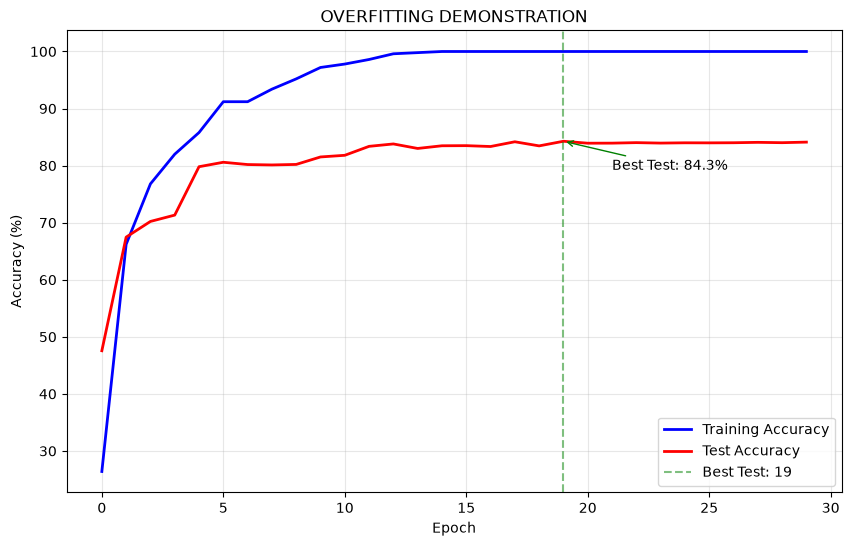

In [15]:
print("\n" + "="*60)
print("SIMPLER MODEL ARCHITECTURE")
print("="*60)

class SimpleModel(nn.Module):
    def __init__(self):
        super(SimpleModel, self).__init__()
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(28*28, 64)   # Much smaller!
        self.fc2 = nn.Linear(64, 10)
        self.relu = nn.ReLU()
    
    def forward(self, x):
        x = self.flatten(x)
        x = self.relu(self.fc1(x))
        x = self.fc2(x)
        return x

print("Training with simpler model (64 neurons)...")
simple_model = SimpleModel()
train_acc_simple, test_acc_simple = train_model(
    simple_model, train_loader_small, test_loader, epochs=30
)

# plot 
plot_train_and_test_accuracy(train_acc_l2, test_acc_l2)


COMPARING REGULARIZATION METHODS


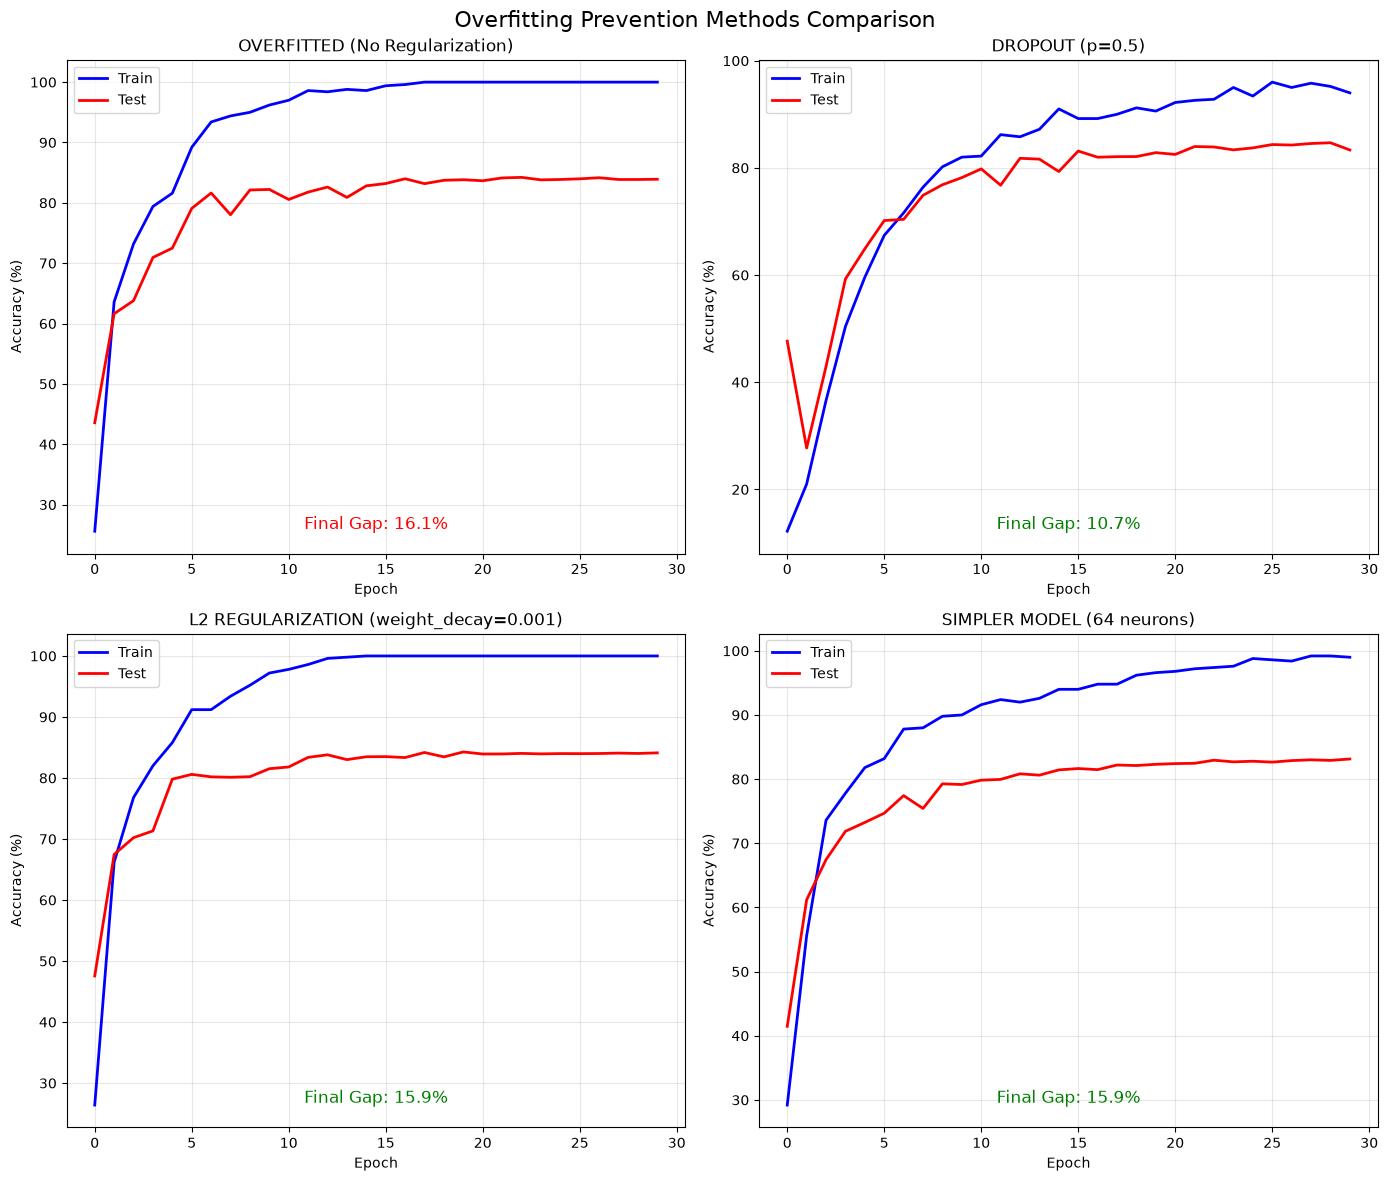

In [17]:
print("\n" + "="*60)
print("COMPARING REGULARIZATION METHODS")
print("="*60)

fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# Plot 1: Overfitting
ax = axes[0, 0]
ax.plot(train_acc_overfit, 'b-', linewidth=2, label='Train')
ax.plot(test_acc_overfit, 'r-', linewidth=2, label='Test')
ax.set_title('OVERFITTED (No Regularization)')
ax.set_xlabel('Epoch')
ax.set_ylabel('Accuracy (%)')
ax.legend()
ax.grid(True, alpha=0.3)
ax.text(0.5, 0.05, f'Final Gap: {train_acc_overfit[-1] - test_acc_overfit[-1]:.1f}%', 
        transform=ax.transAxes, ha='center', fontsize=12, color='red')

# Plot 2: Dropout
ax = axes[0, 1]
ax.plot(train_acc_dropout, 'b-', linewidth=2, label='Train')
ax.plot(test_acc_dropout, 'r-', linewidth=2, label='Test')
ax.set_title('DROPOUT (p=0.5)')
ax.set_xlabel('Epoch')
ax.set_ylabel('Accuracy (%)')
ax.legend()
ax.grid(True, alpha=0.3)
ax.text(0.5, 0.05, f'Final Gap: {train_acc_dropout[-1] - test_acc_dropout[-1]:.1f}%', 
        transform=ax.transAxes, ha='center', fontsize=12, color='green')

# Plot 3: L2 Regularization
ax = axes[1, 0]
ax.plot(train_acc_l2, 'b-', linewidth=2, label='Train')
ax.plot(test_acc_l2, 'r-', linewidth=2, label='Test')
ax.set_title('L2 REGULARIZATION (weight_decay=0.001)')
ax.set_xlabel('Epoch')
ax.set_ylabel('Accuracy (%)')
ax.legend()
ax.grid(True, alpha=0.3)
ax.text(0.5, 0.05, f'Final Gap: {train_acc_l2[-1] - test_acc_l2[-1]:.1f}%', 
        transform=ax.transAxes, ha='center', fontsize=12, color='green')

# Plot 4: Simple Model
ax = axes[1, 1]
ax.plot(train_acc_simple, 'b-', linewidth=2, label='Train')
ax.plot(test_acc_simple, 'r-', linewidth=2, label='Test')
ax.set_title('SIMPLER MODEL (64 neurons)')
ax.set_xlabel('Epoch')
ax.set_ylabel('Accuracy (%)')
ax.legend()
ax.grid(True, alpha=0.3)
ax.text(0.5, 0.05, f'Final Gap: {train_acc_simple[-1] - test_acc_simple[-1]:.1f}%', 
        transform=ax.transAxes, ha='center', fontsize=12, color='green')

plt.suptitle('Overfitting Prevention Methods Comparison', fontsize=16)
plt.tight_layout()
plt.show()